In [8]:
%matplotlib inline
import openmc
import openmc.deplete
import matplotlib.pyplot as plt
import glob
import shutil
import os
import sys
import openmc.examples
import numpy as np
import matplotlib.pyplot as plt
import math
print('Done')

Done


In [9]:
openmc.config['cross_sections'] = '/home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/cross_sections.xml'
output_dir = "/home/kokomoor/reactor_phys_final_proj/Problem6"

In [ ]:
# Here, we input all of our material definitions in order to construct the reactor core per figure 1
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U238', 0.7502, 'wo')
fuel.add_nuclide('U235', 0.1376, 'wo')
fuel.add_nuclide('O16', 0.0897, 'wo')
fuel.add_nuclide('C0', 0.0224, 'wo')
fuel.set_density('g/cc', 10.5)

buff = openmc.Material(name='Buffer')
buff.add_nuclide('C0', 1.0, 'wo')
buff.set_density('g/cm3', 1.0)

iPyC = openmc.Material(name='iPyC')
iPyC.add_nuclide('C0', 1.0, 'wo')
iPyC.set_density('g/cm3', 1.9)

oPyC = openmc.Material(name='oPyC')
oPyC.add_nuclide('C0', 1.0, 'wo')
oPyC.set_density('g/cm3', 1.9)

SiC = openmc.Material(name='SiC')
SiC.add_nuclide('C0', 0.5, 'wo')
SiC.add_element('Si', 0.5, 'wo')
SiC.set_density('g/cm3', 3.2)

coolant = openmc.Material(name='coolant')
#NaFZrF4
coolant.add_nuclide('F19',0.4537, 'wo')
coolant.add_nuclide('Na23',0.1475, 'wo')
coolant.add_nuclide('Zr91',0.3988, 'wo')
coolant.set_density('g/cm3',2.96)

graphite = openmc.Material(name='moderator')
graphite.add_nuclide('C0',  0.99998985, 'wo')
graphite.add_nuclide('B10', 0.00000015, 'wo')
graphite.add_nuclide('N14', 0.00001, 'wo')
graphite.set_density('g/cc', 1.65)

In [ ]:
# Radius of each ring in a single TRISO sphere
r_fuel = 0.02125
r_buffer = 0.03125
r_iPyC = 0.03475
r_SiC = 0.03835
r_oPyC = 0.04225
r_TRISO = 0.04225

# Volume of each material in a single TRISO sphere
V_fuel   = 4/3 * math.pi * r_fuel**3
V_buffer = 4/3 * math.pi * (r_buffer**3 - r_fuel**3)
V_iPyC   = 4/3 * math.pi * (r_iPyC**3 - r_buffer**3)
V_SiC    = 4/3 * math.pi * (r_SiC**3 - r_iPyC**3)
V_oPyC   = 4/3 * math.pi * (r_oPyC**3 - r_SiC**3)
V_TRISO  = 4/3 * math.pi * r_oPyC**3

# A quick sanity check to ensure that the volume of each constituent material in the TRISO sums to
# the total volume of the TRISO sphere
assert (V_fuel + V_buffer + V_iPyC + V_SiC + V_oPyC) == V_TRISO, "Volume fractions should sum to total volume of TRISO"

# The fraction of each materials contribution to the total volume of TRISO material
fuel_frac = V_fuel / V_TRISO
buffer_frac = V_buffer / V_TRISO
iPyC_frac = V_iPyC / V_TRISO
SiC_frac = V_SiC / V_TRISO
oPyC_frac = V_oPyC / V_TRISO

# With the relative fraction of each material in the TRISO known, and the relative fraction of total TRISO material
# to total material in the compact known (packing fraction), we can calculate the fraction of the total compact
# That comes from each individual material
compact_fuel_frac = fuel_frac * 0.35
compact_buffer_frac = buffer_frac * 0.35
compact_iPyC_frac = iPyC_frac * 0.35
compact_SiC_frac = SiC_frac * 0.35
compact_oPyC_frac = oPyC_frac * 0.35
compact_graphite_frac = 0.65 # 1 - packing fraction

# Another useful sanity check to ensure that all relative compact fractions sum to 1
print("This should be 1: ", compact_fuel_frac + compact_buffer_frac + compact_iPyC_frac + compact_SiC_frac + compact_oPyC_frac + compact_graphite_frac)

materials = [fuel, buff, iPyC, SiC, oPyC, graphite]
fractions = [compact_fuel_frac, compact_buffer_frac, compact_iPyC_frac, compact_SiC_frac, compact_oPyC_frac, compact_graphite_frac]

# Get the atomic densities of each constituent nuclide in each material, multiply that atomic density (atoms/b-cm)
# by the compact fraction of the material that nuclide is in, giving the atomic density of that nuclide within the whole compact
# we then iterate over every nuclide in the material, and in cases where the same nuclide is used in several materials, we sum their
# individual densities to arrive at the total atomic density of each nuclide in the mixture, stored in homog_nuclides
# homog_nuclides -> {'<NUCLIDE>': <DENSITY atom/b-cm>}
homog_nuclides = {}  # dictionary to accumulate homogenized densities
for mat, frac in zip(materials, fractions):
    comp = mat.get_nuclide_atom_densities()  # dict of {nuclide: (density, units)}
    for nuclide, dens in comp.items():
        homog_nuclides[nuclide] = homog_nuclides.get(nuclide, 0.0) + dens * frac
#
# fuel_density = 10.5
# buffer_density = 1.0
# iPyC_density = 1.9
# SiC_density = 3.2
# oPyC_density = 1.9
# graphite_density = 1.65

# Define the new homogenous material, assign it a volume matching the total volume of the fuel compact,
# Add all of the nuclide values we just calculated to the new material and set its density to be the
# absolute sum of the constituent densities of the materials being added.
homog_mat = openmc.Material(name="Homogenized Fuel Compact")
total_volume_compact = math.pi*(0.635**2)*2
for nuclide, dens in homog_nuclides.items():
    homog_mat.add_nuclide(nuclide, dens)  # dens is in atom/b-cm units
homog_mat.set_density('sum')  # interpret added nuclide values as absolute densities
homog_mat.volume = total_volume_compact

This should be 1:  1.0
{np.str_('U238'): np.float64(0.0008874742871362338), np.str_('U235'): np.float64(0.00016486092721102575), np.str_('O16'): np.float64(0.0015792789894507051), np.str_('C0'): np.float64(0.07585373766666266), np.str_('Si28'): np.float64(0.002970315030957469), np.str_('Si29'): np.float64(0.00015082412234737), np.str_('Si30'): np.float64(9.942393545082951e-05)}


In [13]:
materials_file = openmc.Materials([fuel, graphite, buff, iPyC, oPyC, SiC,coolant, homog_mat])
materials_file.export_to_xml()

/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists with id=4.
  warn(msg, IDWarning)
/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists with id=5.
  warn(msg, IDWarning)
/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists with id=1.
  warn(msg, IDWarning)
/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists with id=2.
  warn(msg, IDWarning)
/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists with id=6.
  warn(msg, IDWarning)
/home/kokomoor/.conda/envs/openmc-env/lib/python3.10/site-packages/openmc/mixin.py:70: IDWarning: Another Surface instance already exists wi

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Mo92 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo92.h5
 Reading Mo94 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo94.h5
 Reading Mo95 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo96 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo96.h5
 Reading Mo97 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo97.h5
 Reading Mo98 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo98.h5
 Reading Mo99 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo99.h5


 Reading Mo100 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Mo100.h5
 Reading Tc99 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Tc99.h5
 Reading Ru100 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru100.h5
 Reading Ru101 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru101.h5
 Reading Ru102 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru102.h5
 Reading Ru103 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru103.h5
 Reading Ru104 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru104.h5
 Reading Ru105 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru105.h5
 Reading Ru106 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ru106.h5
 Reading Rh103 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Rh103.h5
 Reading Rh105 from
 /home/kokomoor/reactor_phys_final_proj/en

 Reading Xe128 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe128.h5
 Reading Xe130 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe130.h5
 Reading Xe131 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe131.h5
 Reading Xe132 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe132.h5
 Reading Xe133 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe133.h5


...

 Reading Xe134 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe134.h5
 Reading Xe135 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe135.h5
 Reading Xe136 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Xe136.h5
 Reading Cs133 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Cs133.h5
 Reading Cs134 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Cs134.h5
 Reading Cs135 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Cs135.h5
 Reading Cs136 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Cs136.h5


          1200K
          2500K


 Reading Cs137 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba134 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba137 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba140 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La139 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce140 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ce140.h5
 Reading Ce141 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ce141.h5
 Reading Ce142 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ce142.h5
 Reading Ce143 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Ce143.h5
 Reading Ce144 from
 /home/kokomoor/reactor_phys_final_proj/

          1200K
          2500K


 Reading Gd152 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd152.h5
 Reading Gd154 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy160 from
 /home/kokomoor/reactor_phys_final_proj/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from
 /home/kokomoor/reactor_phys_final_proj/

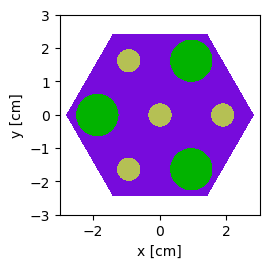

In [ ]:
fuel.temperature = 1000
buff.temperature = 900
iPyC.temperature = 900
oPyC.temperature = 900
SiC.temperature = 900
coolant.temperature = 900
graphite.temperature = 900


# Defines the reflective top and bottom surfaces of the fuel compact
top = openmc.ZPlane(surface_id=4, z0=+1, boundary_type='reflective')
bottom = openmc.ZPlane(surface_id=5, z0=-1, boundary_type='reflective') 

# Geometry definitions
fuel_radius = openmc.ZCylinder(surface_id=1, r=0.635) 
coolant_radius = openmc.ZCylinder(surface_id=2, r=0.35) 

compact_radius = openmc.ZCylinder(surface_id=6, r=0.635) 

# This block defines a fuel radius and a slightly smaller compact radius to avoid situations where TRISOs would be cut by the boundary.
top_compact = openmc.ZPlane(surface_id=7, z0=+0.999)
bottom_compact = openmc.ZPlane(surface_id=8, z0=-0.999) 

# define the compact region as being all area inside of the compact radius, below the top of the compact,
# and above the bottom of the compact
region = -compact_radius & -top_compact & +bottom_compact

fuel_region = -fuel_radius
moder_fuel = +fuel_radius
coolant_region = -coolant_radius 
moder_coolant = +coolant_radius 
 
#Define new cells for the fuel, moderator, graphite, coolant, and moderator
fuel_cell = openmc.Cell(cell_id=1, fill=homog_mat, region=fuel_region)
moder_fuel_cell = openmc.Cell(cell_id=2, fill=graphite, region=moder_fuel)
graphite_cell = openmc.Cell(cell_id=3, fill=graphite)

coolant_cell = openmc.Cell(cell_id=4, fill=coolant, region=coolant_region)
moder_coolant_cell = openmc.Cell(cell_id=5, fill=graphite, region=moder_coolant)

# Define universes around the previously defined cells
fuel_u = openmc.Universe(universe_id=1001, cells=(fuel_cell,moder_fuel_cell))
graphite_u = openmc.Universe(universe_id=1002, cells=[graphite_cell])
coolant_u = openmc.Universe(universe_id=1005, cells=[coolant_cell,moder_coolant_cell])

inner = [coolant_u]
outer = [coolant_u,fuel_u,coolant_u,fuel_u,coolant_u,fuel_u]

#An hexagonal lattice is defined with a fuel universe surrounded by a graphite universe.
hex_lat = openmc.HexLattice(lattice_id=1003, name='assembly')
hex_lat.center = (0., 0.)
hex_lat.pitch = (1.8796,)
hex_lat.orientation = 'x'
hex_lat.outer = graphite_u
hex_lat.universes = [outer, inner]

#An hexagonal bounding box is defined around the lattice.

# Create the prism that will contain the lattice
outer_surface = openmc.model.hexagonal_prism(edge_length=2.8194, orientation='x', boundary_type='reflective')

# Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism.
main_assembly = openmc.Cell(cell_id=7000, fill=hex_lat, region=outer_surface & -top & +bottom)

# Create a universe that contains both 
root = openmc.Universe(cells=[main_assembly])

root.plot(origin = (0,0,0), pixels=(200, 200), width = (6.,6.), color_by = 'material')

geom = openmc.Geometry(root)
geom.export_to_xml()

# OpenMC simulation parameters

lower_left = [-3, -3, -1]
upper_right = [3, 3, 1]
uniform_dist = openmc.stats.Box(lower_left, upper_right)
src = openmc.IndependentSource(space=uniform_dist)#, constraints={'fissionable': True})

settings = openmc.Settings()
settings.source = src
settings.batches = 100
settings.inactive = 25
settings.particles = 2000
settings.temperature = {'method': 'interpolation','range':(293.15,1923.15)}

settings.export_to_xml()

model = openmc.examples.pwr_pin_cell()

model.tallies

# Create equal-lethargy energies to put in filter
energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 501)
e_filter = openmc.EnergyFilter(energies)

model_tallies = openmc.Tallies()

# Create tally with energy filter
flux_tally = openmc.Tally(name='Flux')
flux_tally.filters = [e_filter]
flux_tally.scores = ['flux']
model_tallies.append(flux_tally)

# Set model tallies
model.tallies = model_tallies

openmc.mgxs.GROUP_STRUCTURES.keys()

model.tallies

openmc.run()

fuel.volume = len(trisos)*4/3*3.1416*(212.5*1e-4)**3

depletion_tallies = openmc.Tallies()
depletion_tallies.append(flux_tally)

#These blocks add tallies for U235 Fission and U238 Capture for the depletion run
# --- U-235 Fission Tally ---
u235_fission = openmc.Tally(name='U235 Fission')
u235_fission.scores = ['fission']
u235_fission.nuclides = ['U235']
depletion_tallies.append(u235_fission)

# --- U-238 Capture Tally ---
u238_capture = openmc.Tally(name='U238 Capture')
u238_capture.scores = ['(n,gamma)']
u238_capture.nuclides = ['U238']
depletion_tallies.append(u238_capture)

# Create depletion "operator"
model = openmc.Model(geometry=geom, materials=materials_file, settings=settings, tallies=depletion_tallies)
op = openmc.deplete.CoupledOperator(model, "chain_casl_pwr.xml")

# Perform simulation using the predictor algorithm
# time_steps = [1.0, 2.0, 10.0, 20.0, 30.0]  # days
time_steps = [1.0, 10.0, 100.0, 254.0] # days
power = 1000  
integrator = openmc.deplete.PredictorIntegrator(op, time_steps, power, timestep_units='d')
integrator.integrate()